## Correct for false positives in somatic variant calling

$$ P(\mathrm{FP}_{undiscovered}) = P(\mathrm{FP}) \bigl(1 - P(M_{\mathrm{sampling}})\bigr)$$

- With $ P(FP_{undiscovered}) $ as the probability of an undiscovered false positive.

- With $ P(\mathrm{FP}) $ as the probability of a false positive.
this can be seen as $ P(\mathrm{FP}) = \frac{P(\mathrm{FP}_{discovered})}{P(M_{\mathrm{sampling}})} = \frac{ \frac{N_{false positive}}{N_{total}}}{ P(M_{\mathrm{sampling}}) } $

- With $ P(M_{\mathrm{sampling}}) $ as the Probability that a given variant is sampled in the better-bee population.
  

## extrapolate $P(M_{\mathrm{sampling}})$ from Better-bee data using a variant discovery saturation approach

Variant discovery saturation is a modeling approach used to assess how comprehensively genetic variants have been captured as more individuals are sampled. By plotting the cumulative number of unique variants discovered against the number of samples, one can fit a saturation curve to describe the discovery dynamics. Common models include Michaelis-Menten, negative exponential, or hybrid forms that account for both saturating and non-saturating trends. The asymptote of the fitted curve estimates the total number of discoverable variants, while completeness is calculated as the proportion of discovered variants relative to this asymptote.

#### known issues:
- limited sampling depth relative to the total diversity causes underfitting or misleading extrapolation from models like Michaelis-Menten or the negative exponential . These models assume you have enough of the curve to estimate the asymptote (total SNPs), but when you're far from saturation, their extrapolations become unreliable.
    1. Use nonparametric or semi-parametric methods : Good-Turing Estimator or Chao1 estimator [https://mothur.org/wiki/chao/]
    2. Fit models to the Site Frequency Spectrum (SFS)
    3. Switch to a more flexible model, e,g Weibull function or Log-logistic or logistic growth model
    4. Use constrained fitting informed by external priors

#### The hybrid model for variant discovery is defined as:

$V(n) = a \cdot \left(1 - e^{-b n}\right) + c \cdot n $


Where:
- $ V(n) $: cumulative number of unique variants discovered after sampling \( n \) individuals  
- $ a $: total number of **non-singleton** variants (shared variants that saturate)  
- $ b $: **discovery rate constant** for the exponential (shared variant) component  
- $ c $: average number of **singletons per individual**, which contribute linearly



In [1]:
from variant_discovery_saturation import *
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [3]:
## LOAD VARIANTS
vcf_path = '/media/osmia/taliadoros/raw_data/aligned/sorted/RGed2/merged/BetterB_Batch1_2_3_full_geno_HQ.vcf.gz'
gtarr2 = load_gt_matrix(vcf_path=vcf_path, threads = 10, chr='NC_037638.1')

In [4]:
## RUN DISCOVERY
meanarr, discarr = run_discovery_iter(matrix=gtarr2, n_iter=300)

running iteration0...
running iteration1...
running iteration2...
running iteration3...
running iteration4...
running iteration5...
running iteration6...
running iteration7...
running iteration8...
running iteration9...
running iteration10...
running iteration11...
running iteration12...
running iteration13...
running iteration14...
running iteration15...
running iteration16...
running iteration17...
running iteration18...
running iteration19...
running iteration20...
running iteration21...
running iteration22...
running iteration23...
running iteration24...
running iteration25...
running iteration26...
running iteration27...
running iteration28...
running iteration29...
running iteration30...
running iteration31...
running iteration32...
running iteration33...
running iteration34...
running iteration35...
running iteration36...
running iteration37...
running iteration38...
running iteration39...
running iteration40...
running iteration41...
running iteration42...
running iteration43..

In [5]:
## FIT
a3,b3,c3 = fit_saturation_curve(data=meanarr, fit='hs')

In [6]:
## ESTIMATE COMPLETENESS
completeness = gtarr2.shape[0]/(a3+(c3*gtarr2.shape[1]))
frac_common = a3 / (a3+(c3*gtarr2.shape[1]))
frac_rare = c3*gtarr2.shape[1] / (a3+(c3*gtarr2.shape[1]))

print(f'estimated completeness of the dataset is {np.round(completeness*100, 3)}%')
print(f'estimated common variants are {int(a3)}, making up {np.round(frac_common*100, 2)}% of the dataset ')
print(f'estimated rare variants/singletons are {int(c3*gtarr2.shape[1])}, make up ({np.round(frac_rare*100, 2)}%) of the dataset, with {int(c3)} rare variants per sample ')

estimated completeness of the dataset is 105.428%
estimated common variants are 1751386, making up 61.57% of the dataset 
estimated rare variants/singletons are 1092999, make up (38.43%) of the dataset, with 999 rare variants per sample 


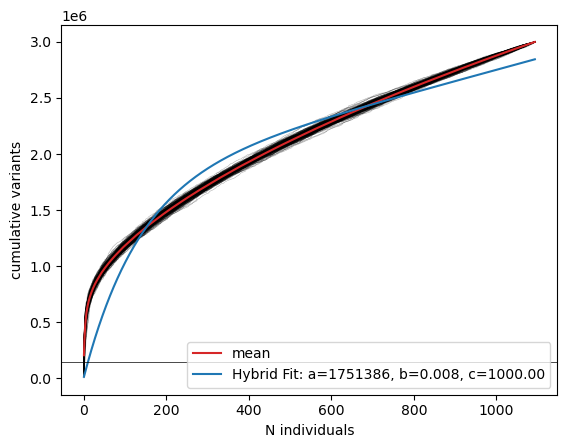

In [9]:
## PLOTTING
for i in discarr[:,]:
    plt.plot(meanarr[:,0], i, color='black', alpha=0.3, lw=0.4)
plt.plot(meanarr[:,0], meanarr[:,1], color='tab:red', label='mean')
plt.plot(meanarr[:,0], hybrid_saturation(meanarr[:,0], a3,b3,c3), color='tab:blue', label=f'Hybrid Fit: a={int(a3)}, b={b3:.3f}, c={c3:.2f}')
plt.legend()
plt.axhline(145935, lw=0.5, color='black')
plt.xlabel("N individuals")
plt.ylabel("cumulative variants")
plt.show()

### estimate $ P(FP_{undiscovered}) $

In [47]:
# LOAD SOMATIC DATA
som_data = pd.read_csv('/home/tilman/Apis/somatic/docker/somatic_muts_with_germ_and_double_new_data.csv', index_col=0)
# TOTAL NUMBER OF DISCOVERED VARIANTS
N_total = som_data.shape[0]
# NUMBER OF DISCOVERED FALSE POSITIVES
N_FP = som_data.germ.sum()

 ## $P(FP_{discovered}) = \frac{N_{FPdiscovered}}{N_{total}}$

In [48]:
FP_disc = N_FP/N_total
print(FP_disc)
print(f' FP_discovered is at {np.round(FP_disc*100, 2)}%')

0.8232153221125943
 FP_discovered is at 82.32%


## $P(FP) = \frac{P(FP_{discovered})}{P(M_{sampling})}$

In [50]:
completeness = 0.9618776111632004
FP_total = FP_disc/completeness

## $P(FP_{undiscovered}) = P(FP_{total})-P(FP_{discovered})$

In [52]:
FP_undisc = FP_total-FP_disc

In [53]:
FP_undisc
print(f'the percentage of undiscovered false positives is {np.round(FP_undisc*100, 3)}%')

the percentage of undiscovered false positives is 3.263%


In [55]:
# TOTAL NUMBER OF UNDISCOVERED FALSE POSITIVES
N_total*FP_undisc

np.float64(281.0793998039223)

In [56]:
# FRACTION OF VARIANTS THAT ARE NOT DISCOVERED FALSE POSITIVES
1-FP_disc

np.float64(0.1767846778874057)

In [57]:
# TOTAL NUMBER OF VARIANTS THAT ARE NOT DISCOVERED FALSE-POSITIVES
np.round(0.1767846778874057*N_total,0)

np.float64(1523.0)

In [79]:
FP_undisc

0.026992712886527825

In [58]:
# TOTAL NUMBER OF VARIANTS THAT ARE LIKELY TRUE POSITIVES
np.round((0.1767846778874057*N_total)-(N_total*FP_undisc),0)

np.float64(1242.0)

In [59]:
Counter(som_data.loc[som_data.germ==0]['sample'])

Counter({'sQ3': 132,
         'nQ10': 118,
         '5wW1': 117,
         '0dQ6': 113,
         'gQ3': 110,
         '0dW8': 105,
         '5wW2': 98,
         '0dW9': 97,
         '0dQ5': 93,
         '9wW1': 91,
         'gQ8': 78,
         'gQ9': 74,
         '0dW7': 71,
         '9wW2': 61,
         '9wW3': 56,
         'nQ9': 43,
         'nQ8': 37,
         '6wW2': 29})

In [63]:
pd.DataFrame(Counter(som_data['sample']), index=[0]).T

,0
0dQ6,488
9wW2,486
0dW7,428
9wW3,288
9wW1,440
nQ10,229
gQ3,346
nQ8,186
0dQ5,330
gQ8,550


In [60]:
pd.DataFrame(Counter(som_data.loc[som_data.germ==0]['sample']), index=[0]).T

,0
0dQ6,113
9wW2,61
0dW7,71
9wW3,56
9wW1,91
nQ10,118
gQ3,110
nQ8,37
0dQ5,93
gQ8,78


In [61]:
pd.DataFrame(Counter(som_data.loc[som_data.germ==1]['sample']), index=[0]).T

,0
0dQ6,375
9wW2,425
0dW7,357
9wW3,232
9wW1,349
nQ10,111
gQ3,236
nQ8,149
0dQ5,237
gQ8,472


In [71]:
Counter(som_data['sample'])

Counter({'test_out_0dQ4': 563,
         'test_out_0dD3': 368,
         'test_out_0dW5': 366,
         'test_out_nQ1': 334,
         'test_out_6wW1': 234,
         'test_out_4wD1': 190})

In [80]:
completeness

0.9718921370582633

In [100]:
res_hp = fit_saturation_curve(data=meanarr, fit='hp')

In [58]:
max(y)>1e7

False

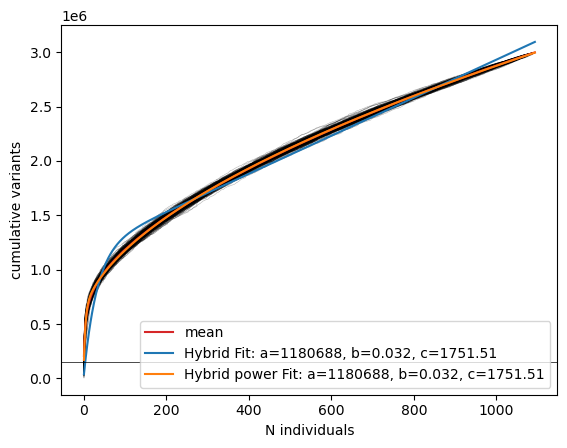

In [65]:
## PLOTTING
for i in discarr[:,]:
    plt.plot(meanarr[:,0], i, color='black', alpha=0.3, lw=0.4)
plt.plot(meanarr[:,0], meanarr[:,1], color='tab:red', label='mean')
plt.plot(meanarr[:,0], hybrid_saturation(meanarr[:,0], a3,b3,c3), color='tab:blue', label=f'Hybrid Fit: a={int(a3)}, b={b3:.3f}, c={c3:.2f}')
plt.plot(meanarr[:,0], hybrid_power(meanarr[:,0], res_hp[0],res_hp[1],res_hp[2],res_hp[3]), color='tab:orange', label=f'Hybrid power Fit: a={int(a3)}, b={b3:.3f}, c={c3:.2f}')

plt.legend()
plt.axhline(145935, lw=0.5, color='black')
plt.xlabel("N individuals")
plt.ylabel("cumulative variants")
plt.show()

In [64]:

fit_val_max = []
for i,k in fpdf.iterrows():
    fit_val_max.append(hybrid_saturation(1093, k[0], k[1], k[2]))
    
    plt.plot(meanarr[:,0],hybrid_saturation(meanarr[:,0], k[0], k[1], k[2]), color='black', alpha=0.3, lw=0.4)
    #plt.plot(meanarr[:,0], meanarr[:,1], color='tab:red', label='mean',lw=0.6)
    plt.plot(meanarr[:,0], hybrid_saturation(meanarr[:,0], a3,b3,c3), color='tab:blue', label=f'Hybrid Fit: a={int(a3)}, b={b3:.3f}, c={c3:.2f}')
plt.show()

NameError: name 'fpdf' is not defined

In [203]:
import sys
print(sys.executable)  # full path to the Python binary Jupyter is using
print(sys.version)     # version string


/home/tilman/miniforge3/bin/python3.10
3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]


In [192]:
import scipy as sc

In [204]:
#from scipy.stats import percentileofscore

 The maximum predicted number of variants is 3132240.0 
 the 95th percentile value is 3118078.0


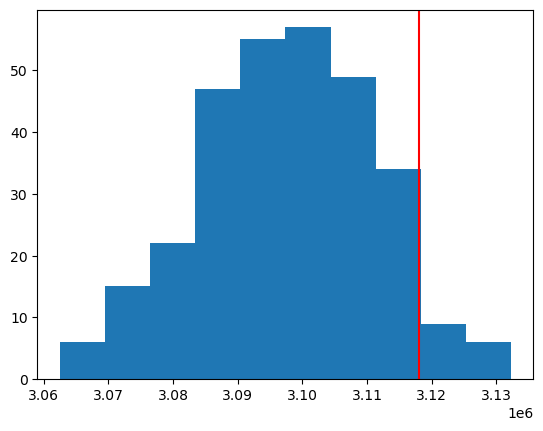

In [222]:
qval, fit_vals, max_val = get_predicted_max_var(discarr=discarr, quantile=0.95, method='hs')

In [226]:
gtarr2.shape[0]/3132240.0

0.9573934308992925

In [227]:
gtarr2.shape[0]/3118078.0

0.9617418165934271

In [5]:
discarr = pd.read_csv('/home/tilman/osmia_store/20250804_nanoseq/sombee_discovery_results_all_chr/discarr.csv', index_col=0)

 The maximum predicted number of variants is 24519182.0 
 the 95th percentile value is 24415364.0


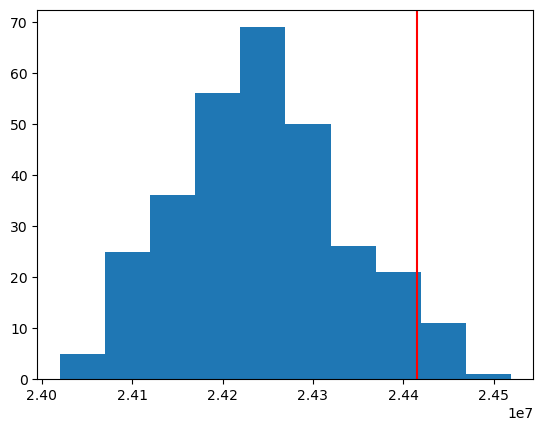

(np.float64(24415364.0),
 [np.float64(24283065.52599553),
  np.float64(24221143.91458437),
  np.float64(24265250.088851683),
  np.float64(24279188.716682397),
  np.float64(24373841.261080317),
  np.float64(24252777.470080886),
  np.float64(24144078.34118372),
  np.float64(24368664.16993626),
  np.float64(24416142.024796106),
  np.float64(24199531.04409506),
  np.float64(24380383.259444717),
  np.float64(24204967.569282293),
  np.float64(24228248.15996519),
  np.float64(24075464.27688758),
  np.float64(24448821.352068394),
  np.float64(24290387.281723604),
  np.float64(24141031.520461805),
  np.float64(24272439.853459798),
  np.float64(24257537.878858853),
  np.float64(24307104.58082818),
  np.float64(24187671.876884542),
  np.float64(24103690.709691264),
  np.float64(24163187.908792183),
  np.float64(24190838.298697855),
  np.float64(24225073.72757373),
  np.float64(24235923.646057196),
  np.float64(24238664.045816038),
  np.float64(24248112.04460016),
  np.float64(24112827.198473714),

In [14]:
get_predicted_max_var(discarr=discarr, quantile=0.95,method='hs')

In [22]:
mean_arr = discarr.mean(axis=0).reset_index()
mean_arr['index']= mean_arr['index'].astype(int)
mean_arr= np.array(mean_arr)

In [43]:
fitd, fit_eval = compare_models(data=mean_arr, models = ['mm', 'ne', 'hs', 'hp'])

In [44]:
fit_eval['AIC']

,mm,ne,hs,hp
mm,0.0,-3956.494546,1952.236924,6438.750081
ne,3956.494546,0.0,5908.731469,10395.244626
hs,-1952.236924,-5908.731469,0.0,4486.513157
hp,-6438.750081,-10395.244626,-4486.513157,0.0


In [ ]:
get_predicted_max_var(discarr)

In [17]:
! zcat /media/osmia/taliadoros/raw_data/aligned/sorted/RGed2/merged/BetterB_Batch1_2_3_full_geno_HQ.vcf.gz | grep -v '#' | wc -l


23484592


In [18]:
23484592/24415364.0

0.9618776111632004

In [19]:
23484592/24519182.0 

0.95780487293581